In [1]:


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
# from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from pmdarima import auto_arima

import os

# === CONFIG ===
os.makedirs("results", exist_ok=True)
seasonal_period = 20  # Adjust based on your data resolution (e.g., 60 mins)
forecast_plot = "results/sarima_packet_count_prediction.png"

# === Load & Combine CSVs ===
file_paths = sorted(glob("./csv_files/*.csv.gz"))
df_list = [pd.read_csv(file) for file in file_paths]
df = pd.concat(df_list, ignore_index=True)

print(f"Loaded {len(df_list)} files.")
# === Parse timestamp and set index ===
# Resample before splitting into train/test
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y%m%d-%H%M%S')
print(df.head())
print(len(df))
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)
# df = df.resample('2T').mean()  # '5T' = 5-minute intervals
df = df.resample(f'{seasonal_period}T').mean().fillna(method='ffill')

print(len(df))

print(f"Data loaded with {len(df)} records.")
# === Split into train/test ===
train_df = df[df.index.date < pd.to_datetime("2021-01-14").date()]
test_df = df[df.index.date == pd.to_datetime("2021-01-14").date()]

y_train = train_df['packet_count']
y_true = test_df['packet_count'].values
n_steps = len(test_df)

print(f"y_train shape: {y_train.shape}")
print(f"NaNs: {y_train.isna().sum()}")
print(f"Unique values: {y_train.nunique()}")
print(f"Range: {y_train.min()} to {y_train.max()}\n\n")

# input("Press Enter to continue...")

# === Fit SARIMA using auto_arima (FAST) ===
# print("Fitting SARIMA model with auto_arima (this will show progress)...")
# model = auto_arima(y_train,
#                    seasonal=True,
#                    m=seasonal_period,
#                    trace=True,
#                    stepwise=True,
#                    suppress_warnings=True,
#                    error_action='ignore',
#                    n_jobs=-1)
from statsmodels.tsa.statespace.sarimax import SARIMAX

import time

seasonality_mins = 1440

with tqdm(total=1, desc="SARIMA (auto_arima)", bar_format="{l_bar}{bar} [elapsed: {elapsed}]", leave=True) as pbar:
    start = time.time()
    model = auto_arima(
                        y_train,
                        seasonal=True,
                        m=seasonality_mins//seasonal_period,  
                        stepwise=True,
                        trace=True,
                        suppress_warnings=True,
                        error_action='ignore',
                        maxiter=25,             # Cap optimization iterations
                        max_p=2, max_q=2,       # Restrict autoregressive & moving avg terms
                        max_d=1,                # Only one differencing term
                        max_P=1, max_Q=1,       # Seasonal terms
                        max_D=1,
                        max_order=10,       # Cap total order
                       )
#     model = SARIMAX(
#     y_train,
#     order=(1, 1, 1),
#     seasonal_order=(1, 1, 1, 24),
#     enforce_stationarity=False,
#     enforce_invertibility=False
# ).fit(disp=False)
    pbar.update(1)
    end = time.time()
    print(f"✅ SARIMA model fitted in {end - start:.2f} seconds.")

# === Forecast ===
y_pred = model.predict(n_periods=n_steps)
forecast_index = test_df.index


Loaded 7 files.
            timestamp  packet_count  avg_packet_size  flow_count  tcp_count  \
0 2021-01-08 00:00:58         12677             64.0       11272      12451   
1 2021-01-08 00:00:59         17122             64.0       14660      16713   
2 2021-01-08 00:01:00         17882             64.0       15650      17462   
3 2021-01-08 00:01:01         62585             64.0       58974      62144   
4 2021-01-08 00:01:02         89039             64.0       55549      88625   

   udp_count  
0          0  
1          0  
2          0  
3          0  
4          0  
563847
505
Data loaded with 505 records.
y_train shape: (432,)
NaNs: 0
Unique values: 401
Range: 7.666666666666667 to 74920.54166666667




SARIMA (auto_arima):   0%|           [elapsed: 00:00]

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[72] intercept   : AIC=8681.127, Time=274.41 sec
 ARIMA(0,1,0)(0,0,0)[72] intercept   : AIC=8725.961, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[72] intercept   : AIC=8714.642, Time=126.97 sec
 ARIMA(0,1,1)(0,0,1)[72] intercept   : AIC=8713.671, Time=148.79 sec
 ARIMA(0,1,0)(0,0,0)[72]             : AIC=8723.963, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[72] intercept   : AIC=8681.715, Time=264.42 sec
 ARIMA(2,1,2)(1,0,0)[72] intercept   : AIC=8680.069, Time=269.70 sec
 ARIMA(2,1,2)(0,0,0)[72] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(1,1,2)(1,0,0)[72] intercept   : AIC=inf, Time=228.78 sec
 ARIMA(2,1,1)(1,0,0)[72] intercept   : AIC=8683.676, Time=211.07 sec
 ARIMA(1,1,1)(1,0,0)[72] intercept   : AIC=8711.097, Time=166.20 sec


SARIMA (auto_arima): 100%|██████████ [elapsed: 31:59]

 ARIMA(2,1,2)(1,0,0)[72]             : AIC=inf, Time=228.51 sec

Best model:  ARIMA(2,1,2)(1,0,0)[72] intercept
Total fit time: 1919.545 seconds
✅ SARIMA model fitted in 1919.68 seconds.


In [ ]:
# !python3.9 -m pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.7 MB/s eta 0:00:00 MB/s eta 0:00:01:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 9.1 MB/s eta 0:00:00m eta 0:00:010:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 9.6 MB/s eta 0:00:000m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 11.9 MB/s eta 0:00:00


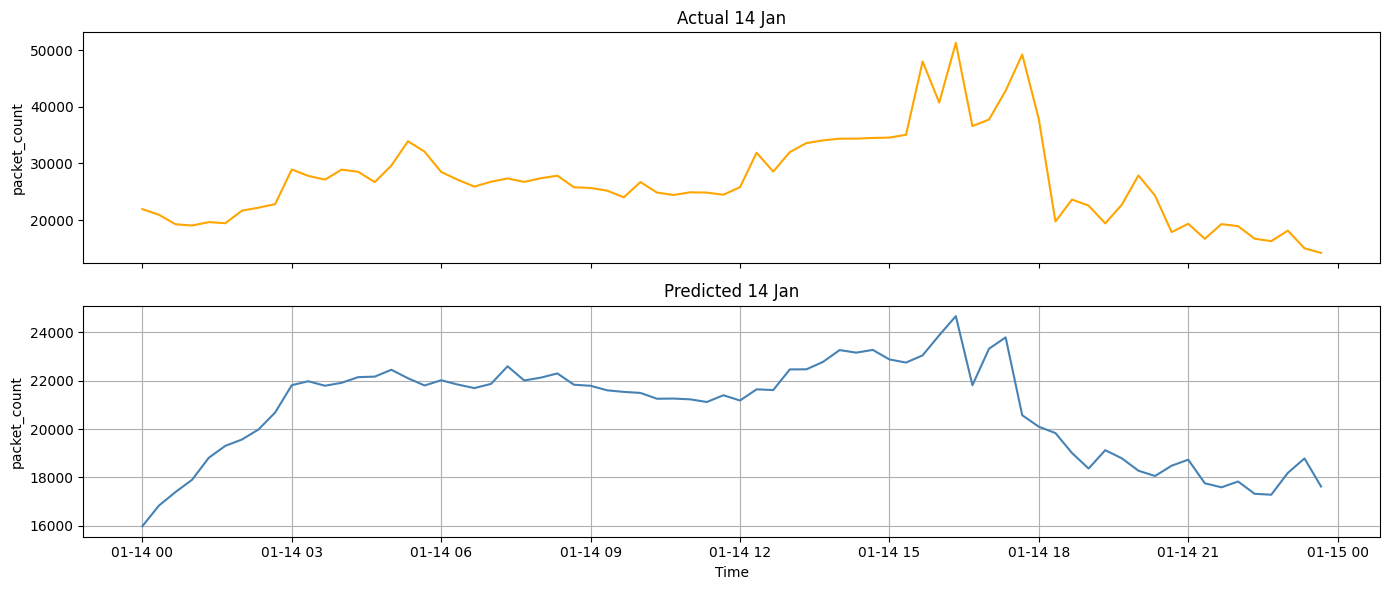


📊 SARIMA Evaluation Metrics:
MAE   : 6670.89
RMSE  : 9030.97
MAPE  : 21.18%
Accuracy within 10%: 23.61%
F1 Score: 23.61


In [3]:
# # === Metrics ===
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100


import matplotlib.pyplot as plt

# Create a figure with 2 subplots (stacked vertically)
fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Plot actual values
axs[0].plot(forecast_index, y_true, color='orange')
axs[0].set_title("Actual 14 Jan")
axs[0].set_ylabel("packet_count")

# Plot predicted values
axs[1].plot(forecast_index, y_pred, color='steelblue')
axs[1].set_title("Predicted 14 Jan")
axs[1].set_ylabel("packet_count")
axs[1].set_xlabel("Time")

# Beautify the layout
plt.tight_layout()
plt.grid(True)
plt.show()



def accuracy_within_tolerance(preds, actuals, threshold=0.10):
    rel_error = np.abs(preds - actuals) / np.maximum(actuals, 1)
    return np.mean(rel_error <= threshold) * 100

accuracy = accuracy_within_tolerance(y_pred, y_true)
f1_score = 2 * (accuracy * accuracy) / (accuracy + accuracy) if accuracy > 0 else 0
# === Print Metrics ===
print("\n📊 SARIMA Evaluation Metrics:")
print(f"MAE   : {mae:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"Accuracy within 10%: {accuracy:.2f}%")

print(f"F1 Score: {f1_score:.2f}")
